In [8]:
import os, io, base64, requests
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import torch.nn as nn
from torch import Tensor

def tensor_from_b64_png(b64: str) -> torch.Tensor:
    raw = base64.b64decode(b64)
    img = Image.open(io.BytesIO(raw))
    if img.size != (32, 32):
        raise ValueError("Expected 32x32 PNG")
    tensor = transforms.ToTensor()(img)  # converts to (3, 32, 32) in [0,1]
    return tensor


def b64_png_from_tensor(tensor: torch.Tensor) -> str:
    img_array = (tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    img = Image.fromarray(img_array)
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    buf.seek(0)
    return base64.b64encode(buf.getvalue()).decode("ascii")


def linf(a: torch.Tensor, b: torch.Tensor) -> float:
    return float(torch.abs(a - b).max())


# Download model weights
weights_path = "cifar10_model_best.pth"
if not os.path.exists(weights_path):
    print("Downloading model weights...")
    resp = requests.get(f"{BASE_URL}/model/weights")
    with open(weights_path, "wb") as f:
        f.write(resp.content)
    print(f"Saved to {weights_path}")

# Load model (assumes model.py from architecture section above)
from model import load_model, NORMALIZATION_MEAN, NORMALIZATION_STD

device = "cuda" if torch.cuda.is_available() else "cpu"
model = load_model(weights_path, device=device)
print(f"Model loaded on {device}")

# Fetch challenge
ch = requests.get(f"{BASE_URL}/challenge", timeout=10).json()
x = tensor_from_b64_png(ch["image"])  # (3, 32, 32)
orig_class = int(ch["original_class"])  # 5 (dog)
target_class = int(ch["target_class"])  # 3 (cat)
epsilon = float(ch["epsilon"])  # 8/255
mean = torch.tensor(ch["normalization"]["mean"]).view(3, 1, 1)
std = torch.tensor(ch["normalization"]["std"]).view(3, 1, 1)

# Verify clean prediction
x_norm = (x - mean) / std
with torch.no_grad():
    pred = model(x_norm.unsqueeze(0).to(device)).argmax(dim=1).item()
print(
    f"Original: class {orig_class}, Target: class {target_class}, Clean pred: {pred}, Epsilon: {epsilon:.6f}"
)


Model loaded on cpu
Original: class 5, Target: class 3, Clean pred: 5, Epsilon: 0.031373


In [11]:




def iterative_fgsm(model: nn.Module,
                   images: Tensor,
                   labels: Tensor,
                   epsilon: float,
                   num_iter: int,
                   alpha: float | None = None,
                   targeted: bool = False,
                   random_start: bool = False) -> Tensor:
    """Iterative FGSM (Basic Iterative Method) with projection.

    Args:
        model: Target classifier in evaluation mode
        images: Clean images (normalized)
        labels: Ground-truth or target labels
        epsilon: L_infinity budget (in normalized space)
        num_iter: Number of iterations
        alpha: Step size per iteration (defaults to epsilon/T)
        targeted: If True, targeted attack
        random_start: If True, initialize within the epsilon ball

    Returns:
        Tensor: Adversarial images (normalized)
    """
    # Valid normalized range for CIFAR-10
    CIFAR_NORM_MIN = (0.0 - max(NORMALIZATION_MEAN)) / max(NORMALIZATION_STD)
    CIFAR_NORM_MAX = (1.0 - min(NORMALIZATION_MEAN)) / min(NORMALIZATION_STD)

    if alpha is None:
        alpha = epsilon / max(num_iter, 1)
    if random_start:
        torch.manual_seed(1337)
        delta = torch.empty_like(images).uniform_(-epsilon, epsilon)
        x_adv = torch.clamp(images + delta, MNIST_NORM_MIN, MNIST_NORM_MAX)
    else:
        x_adv = images.clone()

    for _ in range(num_iter):
        x_adv = x_adv.detach().requires_grad_(True)
        logits = model(x_adv)
        loss = F.cross_entropy(logits, labels)
        model.zero_grad(set_to_none=True)
        loss.backward()
        step_dir = -1.0 if targeted else 1.0
        x_adv = x_adv + step_dir * alpha * x_adv.grad.sign()
        x_adv = torch.clamp(images + (x_adv - images).clamp(-epsilon, epsilon), CIFAR_NORM_MIN, CIFAR_NORM_MAX)

    return x_adv.detach()


In [18]:
# Run targeted I-FGSM
x_norm = x_norm.squeeze(0).unsqueeze(0).to(device)  # ensure (1, 3, 32, 32)
target = torch.tensor([target_class]).to(device)

x_adv_norm = iterative_fgsm(
    model=model,
    images=x_norm,
    labels=target,
    epsilon=epsilon,
    num_iter=100,
    targeted=True,
    random_start=False,
)

# Verify adversarial prediction
with torch.no_grad():
    adv_pred = model(x_adv_norm).argmax(dim=1).item()
print(f"Adversarial pred: {adv_pred} (target: {target_class})")

# Denormalize back to [0,1] for submission
mean_d = mean.to(device)
std_d = std.to(device)
x_adv = (x_adv_norm.squeeze(0) * std_d + mean_d).clamp(0, 1).cpu()

# Verify L-inf constraint on original pixel space
print(f"L-inf distance: {linf(x, x_adv):.6f} (epsilon: {epsilon:.6f})")

# Submit
payload = {"image": b64_png_from_tensor(x_adv)}
result = requests.post(f"{BASE_URL}/submit", json=payload, timeout=10).json()
print(result)

Adversarial pred: 3 (target: 3)
L-inf distance: 0.008207 (epsilon: 0.031373)
{'flag': 'HTB{f1r57_0rd3r_fun}', 'message': 'Congratulations! Challenge solved!', 'success': True, 'validation': {'adversarial_class': 'cat', 'adversarial_prediction': 3, 'changed_pixel_ratio': 0.8828125, 'direction_check': True, 'gradient_alignment': 0.8053385615348816, 'linf_constraint': '≤ 0.031373', 'linf_norm': 0.011764734983444214, 'linf_satisfied': True, 'sufficient_coverage': True, 'target_achieved': True, 'target_class': 'cat', 'valid_range': True}}


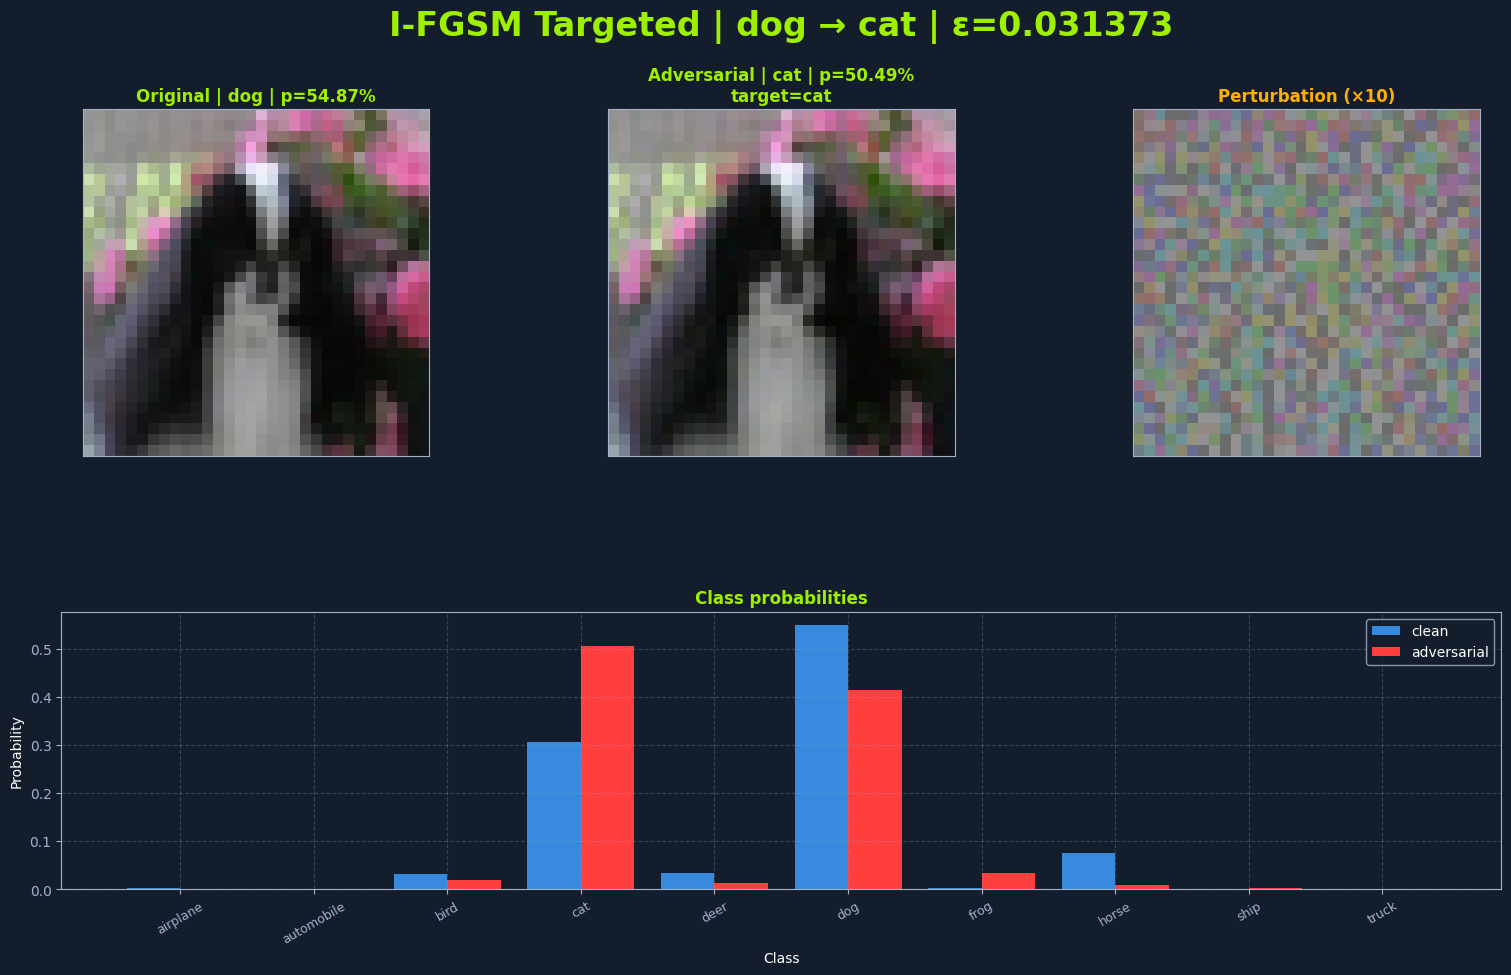

In [21]:
###################################
# VISUALIZATION
###################################

import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from model import CIFAR10_CLASSES

# HTB color constants (matching htb_ai_library)
HTB_GREEN     = "#9fef00"
NODE_BLACK    = "#141d2b"
HACKER_GREY   = "#a4b1cd"
WHITE         = "#ffffff"
AZURE         = "#378add"
NUGGET_YELLOW = "#ffaf00"
MALWARE_RED   = "#ff3e3e"
VIVID_PURPLE  = "#9b59b6"
AQUAMARINE    = "#1abc9c"


def _style_axes(ax: plt.Axes) -> None:
    """Apply Hack The Box dark theme to an axes instance.

    Args:
        ax: Matplotlib axes to style
    """
    ax.set_facecolor(NODE_BLACK)
    ax.tick_params(colors=HACKER_GREY)
    for spine in ax.spines.values():
        spine.set_color(HACKER_GREY)
    ax.grid(True, color=HACKER_GREY, linestyle="--", alpha=0.25)


def visualize_attack(model: nn.Module,
                     x_orig: Tensor,
                     x_adv: Tensor,
                     mean: Tensor,
                     std: Tensor,
                     orig_class: int,
                     target_class: int,
                     epsilon: float,
                     device: str,
                     title: str = "I-FGSM Targeted") -> None:
    """Core HTB-styled visualization for CIFAR-10 adversarial attacks.

    Shows original image, adversarial image, perturbation panel, and a
    class-probability bar chart comparing clean vs adversarial confidence.

    Args:
        model: Classifier in evaluation mode
        x_orig: Original image tensor (3,32,32) in [0,1] pixel space
        x_adv: Adversarial image tensor (3,32,32) in [0,1] pixel space
        mean: Normalization mean tensor (3,1,1)
        std: Normalization std tensor (3,1,1)
        orig_class: Ground-truth class index
        target_class: Desired target class index
        epsilon: L-inf perturbation budget
        device: Torch device string
        title: Main figure title prefix
    """
    model.eval()

    # Normalize for model inference
    x_orig_norm = ((x_orig - mean) / std).unsqueeze(0).to(device)
    x_adv_norm  = ((x_adv  - mean) / std).unsqueeze(0).to(device)

    # Compute probabilities from live model
    with torch.no_grad():
        clean_probs = F.softmax(model(x_orig_norm), dim=1).squeeze(0).cpu()
        adv_probs   = F.softmax(model(x_adv_norm),  dim=1).squeeze(0).cpu()
    clean_pred = int(clean_probs.argmax())
    adv_pred   = int(adv_probs.argmax())

    # Perturbation scaled for visibility (×10, centred at 0.5)
    pert_vis = ((x_adv - x_orig) * 10 + 0.5).clamp(0, 1)

    # ── Layout ────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 10), facecolor=NODE_BLACK)
    gs  = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.35,
                           height_ratios=[1, 0.8])

    # ── Panel 1 : Original image ──────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    _style_axes(ax1)
    ax1.imshow(x_orig.permute(1, 2, 0).numpy())
    ax1.set_title(
        f"Original | {CIFAR10_CLASSES[clean_pred]} | p={clean_probs[clean_pred]:.2%}",
        color=HTB_GREEN, fontweight="bold"
    )
    ax1.set_xticks([])
    ax1.set_yticks([])

    # ── Panel 2 : Adversarial image ───────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    _style_axes(ax2)
    ax2.imshow(x_adv.permute(1, 2, 0).numpy())
    title_color = HTB_GREEN if adv_pred == target_class else MALWARE_RED
    ax2.set_title(
        f"Adversarial | {CIFAR10_CLASSES[adv_pred]} | p={adv_probs[adv_pred]:.2%}\n"
        f"target={CIFAR10_CLASSES[target_class]}",
        color=title_color, fontweight="bold"
    )
    ax2.set_xticks([])
    ax2.set_yticks([])

    # ── Panel 3 : Perturbation (scaled for visibility) ───────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    _style_axes(ax3)
    ax3.imshow(pert_vis.permute(1, 2, 0).numpy())
    ax3.set_title("Perturbation (×10)", color=NUGGET_YELLOW, fontweight="bold")
    ax3.set_xticks([])
    ax3.set_yticks([])

    # ── Panel 4 : Class probability comparison bar chart ─────────────────
    ax4 = fig.add_subplot(gs[1, :])
    _style_axes(ax4)
    idx   = np.arange(len(CIFAR10_CLASSES))
    width = 0.4
    ax4.bar(idx - width / 2, clean_probs.numpy(), width,
            color=AZURE,       label="clean")
    ax4.bar(idx + width / 2, adv_probs.numpy(),   width,
            color=MALWARE_RED, label="adversarial")
    ax4.set_xticks(idx)
    ax4.set_xticklabels(CIFAR10_CLASSES, rotation=30,
                        color=HACKER_GREY, fontsize=9)
    ax4.set_xlabel("Class",       color=WHITE)
    ax4.set_ylabel("Probability", color=WHITE)
    for text in ax4.get_yticklabels():
        text.set_color(HACKER_GREY)
    legend = ax4.legend(facecolor=NODE_BLACK, edgecolor=HACKER_GREY)
    for t in legend.get_texts():
        t.set_color(WHITE)
    ax4.set_title("Class probabilities", color=HTB_GREEN, fontweight="bold")

    # ── Main title ────────────────────────────────────────────────────────
    fig.suptitle(
        f"{title} | {CIFAR10_CLASSES[orig_class]} → {CIFAR10_CLASSES[target_class]}"
        f" | ε={epsilon:.6f}",
        color=HTB_GREEN, fontweight="bold", fontsize=24, y=0.98
    )
    plt.subplots_adjust(top=0.88, bottom=0.1, left=0.05, right=0.95)
    plt.show()


def visualize_ifgsm_targeted(model: nn.Module,
                              x_orig: Tensor,
                              x_adv: Tensor,
                              mean: Tensor,
                              std: Tensor,
                              orig_class: int,
                              target_class: int,
                              epsilon: float,
                              device: str) -> None:
    """Wrapper for visualize_attack tuned for targeted I-FGSM on CIFAR-10.

    Mirrors the visualize_ifgsm() wrapper style from the demo notebook:
    delegates to the core visualize_attack function with a fixed title.

    Args:
        model: Classifier in evaluation mode
        x_orig: Original image tensor (3,32,32) in [0,1] pixel space
        x_adv: Adversarial image tensor (3,32,32) in [0,1] pixel space
        mean: Normalization mean tensor (3,1,1)
        std: Normalization std tensor (3,1,1)
        orig_class: Ground-truth class index
        target_class: Desired target class index
        epsilon: L-inf perturbation budget
        device: Torch device string
    """
    visualize_attack(
        model, x_orig, x_adv,
        mean, std,
        orig_class, target_class,
        epsilon, device,
        title="I-FGSM Targeted"
    )


# ── Call with your existing variables ────────────────────────────────────────
# x        : original image (3,32,32) in [0,1]  — from tensor_from_b64_png()
# x_adv    : adversarial image (3,32,32) in [0,1] — denormalized after attack
# mean/std : challenge normalization tensors (3,1,1)
# orig_class / target_class / epsilon / device — all from challenge fetch

visualize_ifgsm_targeted(model, x, x_adv, mean, std,
                         orig_class, target_class, epsilon, device)

Fetching challenge...
Saved original image → challenge_images/original_challenge.png
Saved upscaled images → challenge_images/


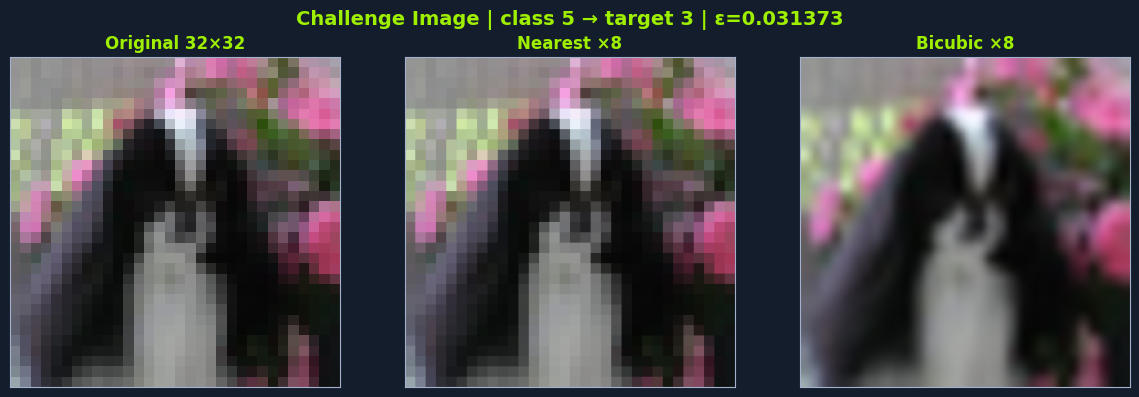

Done.


In [22]:
"""
Download and save the HTB challenge image locally for inspection.
Run this in your notebook or as a standalone script.
"""

import os
import io
import base64
import requests
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# ── Config ────────────────────────────────────────────────────────────────────
# BASE_URL should already be defined in your notebook environment
# If running standalone, set it here:
# BASE_URL = "http://<challenge-host>:<port>"

SAVE_DIR = "challenge_images"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Fetch challenge ───────────────────────────────────────────────────────────
print("Fetching challenge...")
ch = requests.get(f"{BASE_URL}/challenge", timeout=10).json()

orig_class  = int(ch["original_class"])
target_class = int(ch["target_class"])
epsilon     = float(ch["epsilon"])

# ── Decode image from base64 PNG ──────────────────────────────────────────────
raw  = base64.b64decode(ch["image"])
img  = Image.open(io.BytesIO(raw)).convert("RGB")

# ── Save original image ───────────────────────────────────────────────────────
save_path = os.path.join(SAVE_DIR, "original_challenge.png")
img.save(save_path)
print(f"Saved original image → {save_path}")

# ── Upscale for easier viewing (32x32 is tiny) ───────────────────────────────
scale      = 8                                    # 32x32 → 256x256
img_big    = img.resize((32 * scale, 32 * scale), Image.NEAREST)   # pixel-perfect
img_smooth = img.resize((32 * scale, 32 * scale), Image.BICUBIC)   # smoothed

img_big.save(os.path.join(SAVE_DIR, "original_nearest_x8.png"))
img_smooth.save(os.path.join(SAVE_DIR, "original_smooth_x8.png"))
print(f"Saved upscaled images → {SAVE_DIR}/")

# ── Quick matplotlib display ──────────────────────────────────────────────────
NODE_BLACK = "#141d2b"
HTB_GREEN  = "#9fef00"

fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor=NODE_BLACK)
fig.suptitle(
    f"Challenge Image | class {orig_class} → target {target_class} | ε={epsilon:.6f}",
    color=HTB_GREEN, fontweight="bold", fontsize=14
)

for ax, image, label in zip(
    axes,
    [img, img_big, img_smooth],
    ["Original 32×32", "Nearest ×8", "Bicubic ×8"]
):
    ax.imshow(np.array(image))
    ax.set_title(label, color=HTB_GREEN, fontweight="bold")
    ax.set_facecolor(NODE_BLACK)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color("#a4b1cd")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "challenge_preview.png"),
            dpi=150, bbox_inches="tight", facecolor=NODE_BLACK)
plt.show()
print("Done.")